# Hiram Option Pricing Library

## Visualizing Payoffs and Pricing Option Strategies

The main topic of this notebook will be the **visualization of payoffs** and  the **pricing of option strategies** 

(Straddle/Strangle/Spreads/etc..).

**Dont hesitate to read it from my website, I think it's way better from there : [Article Link](https://paulboquant.com/blog/post-2/)**

Hiram is a free financial library built in Python that can be use for option pricing and financial instruments management. The purpose of this project is to show how easy Python is to use. And to
improve my ability to model complex financial products in an object-oriented fashion.

**Links**
- [My Website](https://paulboquant.com/)
- [Github repo](https://github.com/paulbqnt/hiram)
- [LinkedIn](https://www.linkedin.com/in/paulboquant/)
- [Youtube video](https://www.youtube.com/watch?v=he_yCcZ_YVU)

### **Table of Content**

1. [Option creation and Pricing](#section-one)
2. [Call and Put Vizualization](#section-four)
3. [Straddle](#section-five)
4. [Strangle](#section-five)
5. [Strip](#section-five)
6. [Strap](#section-five)
7. [Put Call Parity Review](#section-putcall)
8. [Bull Call Spread](#section-five)
9. [Bear Put Spread](#section-five)
10. [Butterfly Spread](#section-five)
11. [Digital Replication](#section-five)


## Introduction 

I was wrong about my project architecture. My main goal was to make the code as concise and easy to use as possible. 

I realized that this way was wrong as I tried to add new options/models.

So I gave up on my old python class

```python
# Old
example_call = BlackScholes(way=Way_option.call, S=100, K=105, T=1, r=0.05, sigma=0.3)
```

This one allowed you to declare and price in a single line of code.

I've replaced it with the one below, which is more robust, more prod-oriented and more maintainable over time, as my project evolves.

In [3]:
# New
call = VanillaOption(style="euro", k=100, t=.2, way="call")
bsm = BlackScholesModel(spot=100, r=.05, sigma=.35)
call.pricer(model=bsm)

{'spot': 100.0,
 'strike': 100.0,
 'maturity': 0.2,
 'value': 6.717176287682648,
 'sigma': 0.35,
 'r': 0.05,
 'delta': 0.550981792606417,
 'gamma': 0.025231275699541374,
 'vega': 0.17661892989678962,
 'theta': -17.90089380999719,
 'rho': 7.8986386672498305,
 'way': 'call',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:08'}

VanillaOption() only includes information related to the option you wish to create. 

In [ ]:
VanillaOption(style="euro", k=100, t=.2, way="call")

BlackScholesModel() incorporates the market parameters at time $t$.

In [ ]:
BlackScholesModel(spot=100, r=.05, sigma=.35)

Finally, a call to the **pricer() method** returns and integrates the option's pricing according to the model chosen inside the VanillaOption() object.

In [4]:
call.pricer(model=bsm)
call.dict()

{'way': 'call',
 'k': 100.0,
 't': 0.2,
 'qty': 1,
 'price': 1,
 'q': 0,
 'style': 'euro',
 'stock': None,
 'id_': UUID('85e7a33b-bfbb-41ab-a523-f88764bb5f8a'),
 'pricing_data': {'spot': 100.0,
  'strike': 100.0,
  'maturity': 0.2,
  'value': 6.717176287682648,
  'sigma': 0.35,
  'r': 0.05,
  'delta': 0.550981792606417,
  'gamma': 0.025231275699541374,
  'vega': 0.17661892989678962,
  'theta': -17.90089380999719,
  'rho': 7.8986386672498305,
  'way': 'call',
  'model': 'BlackScholes',
  'pricing_date': '2023-07-18 13:50:18'}}

### Setup

In [1]:
# This setup helps us to import files from parent directory

import sys
import os

current = os.path.dirname(os.path.realpath("example2_StrategiesPlot.ipynb"))
parent = os.path.dirname(current)

sys.path.append(parent)

<a id="section-one"></a>
### **1. Option creation and Pricing**

In [2]:
from option import VanillaOption
from model import BlackScholesModel

call = VanillaOption(k=120, t=.5, style="euro", way="call")
bsm = BlackScholesModel(spot=100, r=.05, sigma=.35)
call.pricer(model=bsm)

{'spot': 100.0,
 'strike': 120.0,
 'maturity': 0.5,
 'value': 4.241905955485716,
 'sigma': 0.35,
 'r': 0.05,
 'delta': 0.29683509553802406,
 'gamma': 0.014139967994435582,
 'vega': 0.24744943990262272,
 'theta': -9.970382657604757,
 'rho': 17.497317695595758,
 'way': 'call',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:05'}

In [5]:
put = VanillaOption(k=120, t=.5, style="euro", way="put")
bsm = BlackScholesModel(spot=100, r=.05, sigma=.35)
put.pricer(model=bsm)

{'spot': 100.0,
 'strike': 120.0,
 'maturity': 0.5,
 'value': 21.27909539888563,
 'sigma': 0.35,
 'r': 0.05,
 'delta': -0.6784748164903085,
 'gamma': 0.014139967994435582,
 'vega': 0.24744943990262272,
 'theta': -8.648285993273557,
 'rho': -17.497317695595758,
 'way': 'put',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:24'}

<a id="section-two"></a>
### **2. Call and Put Vizualization**

In both introductory option pricing courses and interview preparation, I've always found that the hardest part is **creating a pricing intuition**.

I imagine that this intuition is developed as you use these products in a professional environment.

Nevertheless, I wanted to start this project as an aid to quickly pricing options, and visualizing how options and Greeks behave.

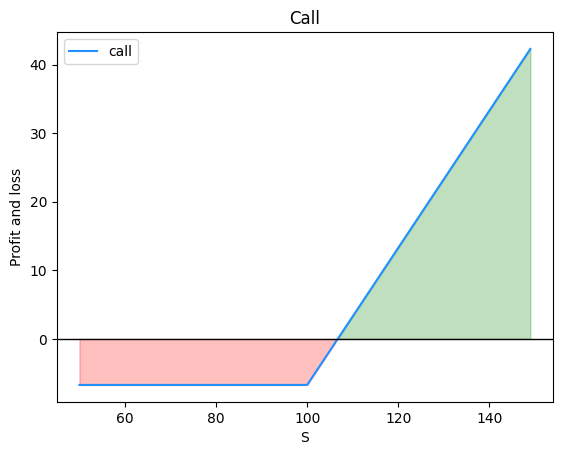

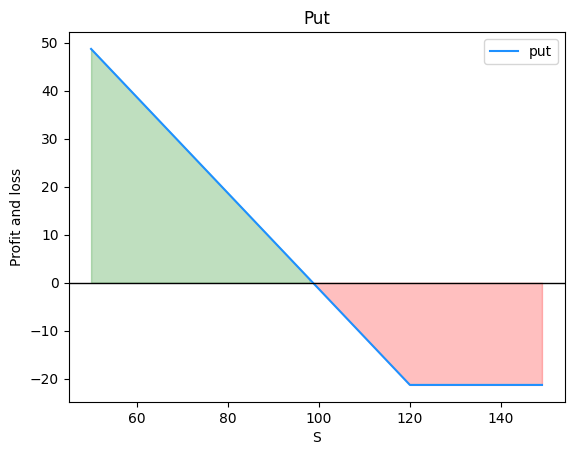

In [6]:
from plot import plot_payoff_vanilla
plot_payoff_vanilla(call)
plot_payoff_vanilla(put)

<a id="section-three"></a>
### **3. Straddle**

A straddle is a neutral option strategy that involves simultaneously buying both a put option and a call option for the underlying security with the same strike price and the same expiration date.

  A trader will profit from a long straddle when the price of the security rises or falls from the strike price by an amount more than the total cost of the premium paid. The profit potential is virtually unlimited, so long as the price of the underlying security moves very sharply.  

In [7]:
from strategy import Strategy

straddle = Strategy(style="straddle", k=100, t=.2)
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
straddle.pricer(model=bsm)

{'spot': 100.0,
 'strike': 100.0,
 'maturity': 0.2,
 'value': 10.673011477869338,
 'sigma': 0.3,
 'r': 0.05,
 'delta': 0.11149739872349529,
 'gamma': 0.05887742397944973,
 'vega': 0.35326454387669837,
 'theta': -28.97794416820853,
 'rho': 0.0,
 'way': 'long',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:30'}

In the aim of being more business-oriented, I preferred to change the output format to a dictionary/json. 

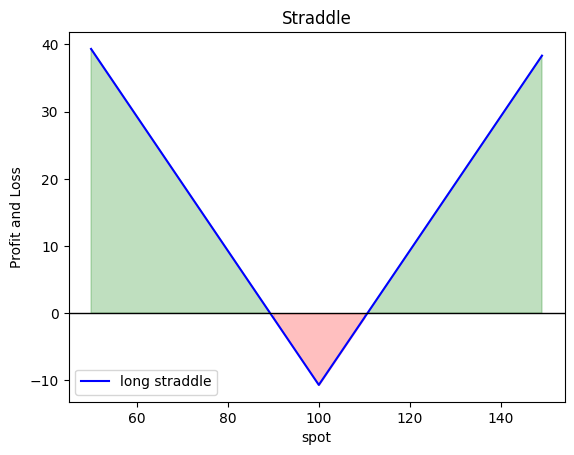

In [8]:
from plot import plot_payoff_straddle
plot_payoff_straddle(straddle)

If you expect the price of the underlying asset to fluctuate only slightly and/or volatility to fall. You can sell the straddle and earn the premium.

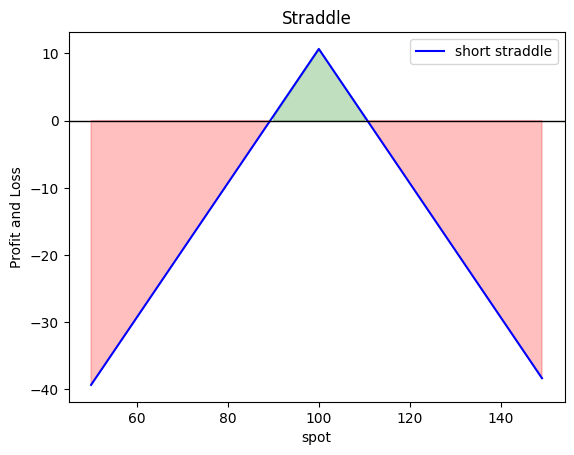

In [9]:
straddle.qty = -1
plot_payoff_straddle(straddle)

<a id="section-four"></a>
### **4. Strangle**

The **Strangle** may be a good fit if you think the underlying will experience a large price movement in the near future but you are not sure about the direction.

In [10]:
strangle = Strategy(style="strangle", k=85, k2=110, t=.2)
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
strangle.pricer(model=bsm)

{'spot': 100.0,
 'strike': 85.0,
 'maturity': 0.2,
 'value': 2.8005984368016907,
 'sigma': 0.3,
 'r': 0.05,
 'delta': 0.19476064934303597,
 'gamma': 0.03720086834246779,
 'vega': 0.2232052100548067,
 'theta': -18.05165932804553,
 'rho': 3.5923390491831757,
 'way': 'long',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:38'}

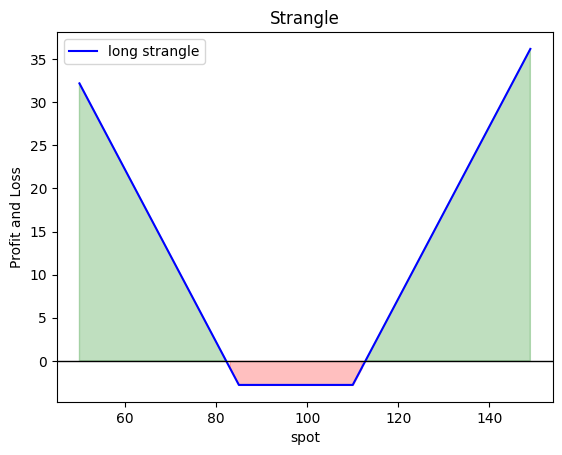

In [11]:
from plot import plot_payoff_strangle
plot_payoff_strangle(strangle)

You could still sell the Strangle if you dont forecast volatility in the future.

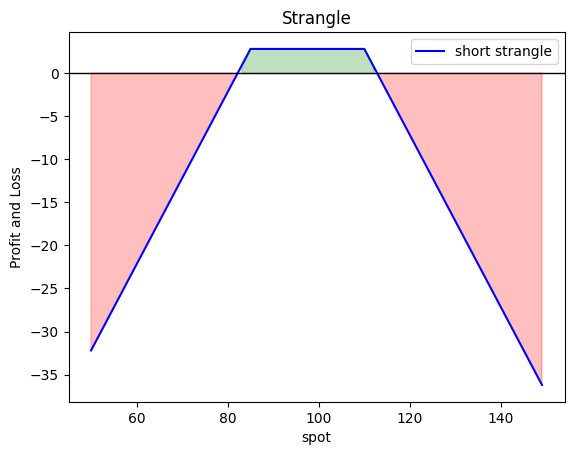

In [12]:
# Let's say you want to instead short the straddle
strangle.qty = -1
plot_payoff_strangle(strangle)

<a id="section-five"></a>
### **5. Strip**

A strip is essentially a long straddle, but instead utilizes two puts and one call instead of one of each.

Strip may be considered as a market neutral bearish strategy. It pays off relatively more when the underlying asset declines than when it rises.

In [13]:
strip = Strategy(k=100, k2=110, t=.5, style="strip")
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
strip.pricer(bsm)

{'spot': 100.0,
 'strike': 100.0,
 'maturity': 0.5,
 'value': 23.966612291014094,
 'sigma': 0.3,
 'r': 0.05,
 'delta': -0.2284494342456168,
 'gamma': 0.0550221481945368,
 'vega': 0.825332222918052,
 'theta': -27.20793364151202,
 'rho': -19.453267051904064,
 'way': 'long',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:45'}

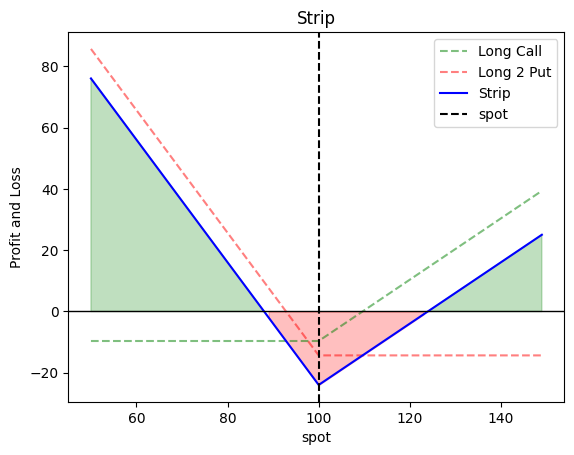

In [14]:
from plot import plot_payoff_strip
plot_payoff_strip(strip)

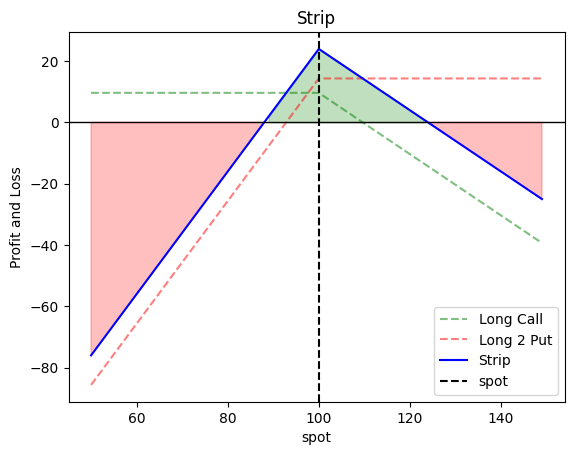

In [15]:
# Let's say you want to instead short the Strip
strip.qty = -1
plot_payoff_strip(strip)

<a id="section-six"></a>
### **6. Strap**

A strap is an options combination that involves purchasing two at the money calls and one at the money put.

Strap may be considered as a market neutral bullish strategy. It pays off relatively more when the underlying asset rises than when it declines.

In [16]:
strap = Strategy(k=100, k2=110, t=.5, style="strap")
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
strap.pricer(bsm)

{'spot': 100.0,
 'strike': 100.0,
 'maturity': 0.5,
 'value': 26.435621088180824,
 'sigma': 0.3,
 'r': 0.05,
 'delta': 0.7468604777827158,
 'gamma': 0.0550221481945368,
 'vega': 0.825332222918052,
 'theta': -29.675752769374895,
 'rho': 19.453267051904064,
 'way': 'long',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:50'}

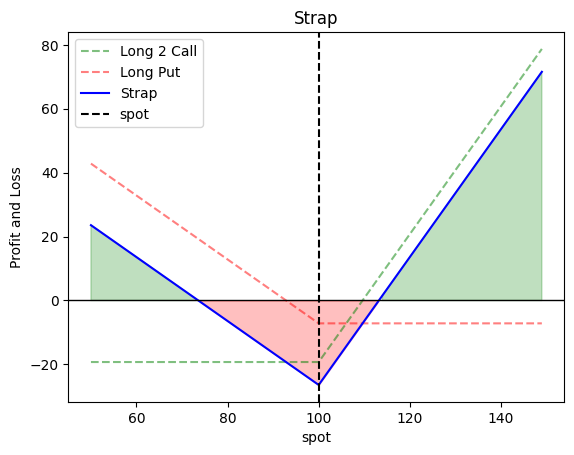

In [17]:
from plot import plot_payoff_strap
plot_payoff_strap(strap)

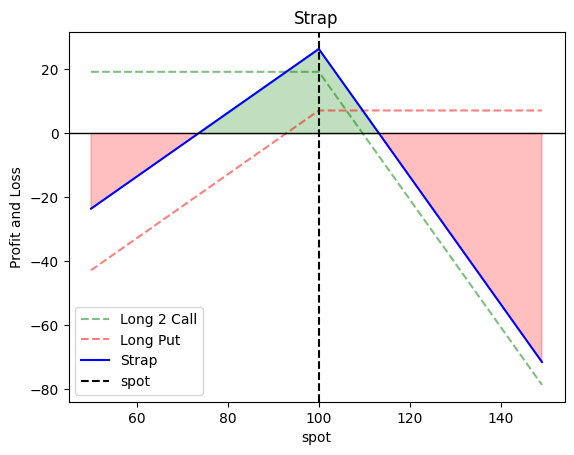

In [18]:
# Let's say you want to instead short the Strap
strap.qty = -1
plot_payoff_strap(strap)

<a id="section-seven"></a>
### **7. Bull Call Spread**

Bull spread may be the good strategy if you have a bullish view on the market. Bull Spread is designed to profit from a moderate rise in the price of the underlying security. 

You can also model the bull spread with puts. I will add this feature in the future.

In [19]:
bull_spread = Strategy(k=80, k2=120, t=.5, style="bull_spread",qty=1, way="call")
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
bull_spread.pricer(model=bsm)

{'spot': 100.0,
 'strike': 80.0,
 'maturity': 0.5,
 'value': 26.13327748374865,
 'sigma': 0.3,
 'r': 0.05,
 'delta': 0.6207439807990514,
 'gamma': -0.007033223116091418,
 'vega': -0.10549834674137129,
 'theta': -1.336009490916319,
 'rho': 25.138651886972593,
 'way': 'call',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:50:57'}

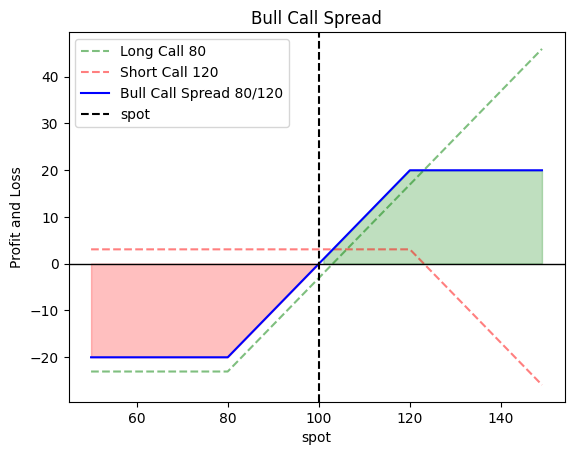

In [20]:
from plot import plot_payoff_bull_spread
plot_payoff_bull_spread(bull_spread)

<a id="section-putcall"></a>
### **7. Put Call Parity Review**



It's crucial to understand what's the **put call-parity**. I've been asked about this several times in interviews.

The put–call parity defines a relationship between the price of a European call and European put, both with the identical strike price and expiry, namely that a portfolio of a long call option and a short put option is equivalent to (and hence has the same value as) a single forward contract at this strike price and expiry. This is because if the price at expiry is above the strike price, the call will be exercised, while if it is below, the put will be exercised, and thus in either case one unit of the asset will be purchased for the strike price, exactly as in a forward contract. 

$$\boxed{c + Ke^{-r * T} = p + S_{0}}$$

$c = \text{European Call} $

$p = \text{European Put}$

$Ke^{-r \times T} = \text{Present value of strike price (same strike for call and put)}$



**Why this formula is crucial ?**

The put-call parity theory is important to understand because this relationship must hold in theory. With European put and calls, if this relationship does not hold, then that leaves an opportunity for arbitrage.

Rearranging this formula, we can solve for any of the components of the equation. This allows us to create a synthetic call or put option. 

If a portfolio of the synthetic option costs less than the actual option, based on put-call parity, a trader could employ an arbitrage strategy to profit.


<a id="section-eight"></a>
### **8. Bear Put Spread**

A Bear Spread is a bearish, vertical spread options strategy that can be used when the options trader is moderately bearish on the underlying security.

Because of put–call parity, a bear spread can be constructed using either put options or call options. If constructed using calls, it is a bear call spread (alternatively call credit spread). If constructed using puts, it is a bear put spread (alternatively put debit spread). 

In [21]:
bear_spread = Strategy(k=80, k2=120, t=.5, style="bear_spread",qty=1, way="call")
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
bear_spread.pricer(model=bsm)

{'spot': 100.0,
 'strike': 80.0,
 'maturity': 0.5,
 'value': 26.13327748374865,
 'sigma': 0.3,
 'r': 0.05,
 'delta': -0.6207439807990514,
 'gamma': 0.007033223116091418,
 'vega': 0.10549834674137129,
 'theta': -7.665910295398596,
 'rho': 25.138651886972593,
 'way': 'call',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:51:01'}

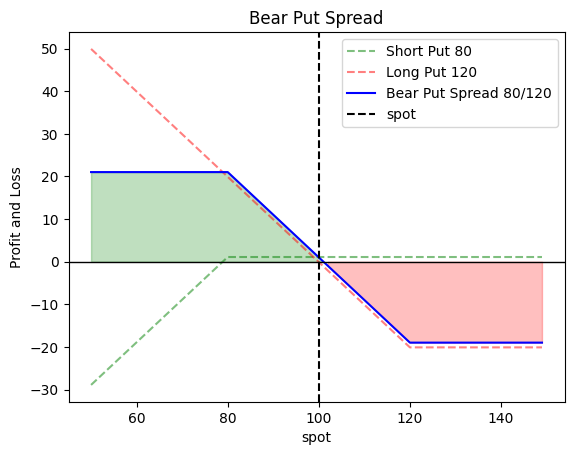

In [22]:
from plot import plot_payoff_bear_spread
plot_payoff_bear_spread(bear_spread)

<a id="section-nine"></a>
### **9. Butterfly Spread**

A butterfly is a limited risk, non-directional options strategy that is designed to have a high probability of earning a limited profit when the future volatility of the underlying asset is expected to be lower (when long the butterfly) or higher (when short the butterfly) than that asset's current implied volatility.

In [23]:
butterfly_spread = Strategy(k=80, k2=100, k3=120, t=.5, style="butterfly_spread",qty=1)
bsm = BlackScholesModel(spot=100, r=0.05, sigma=0.3)
butterfly_spread.pricer(model=bsm)

{'spot': 100.0,
 'strike': 80.0,
 'maturity': 0.5,
 'value': 45.40303074064702,
 'sigma': 0.3,
 'r': 0.05,
 'delta': -0.015266988082805966,
 'gamma': -0.012980483837469445,
 'vega': -0.1947072575620417,
 'theta': -3.582145639427016,
 'rho': 64.04518599078072,
 'way': 'long',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:51:05'}

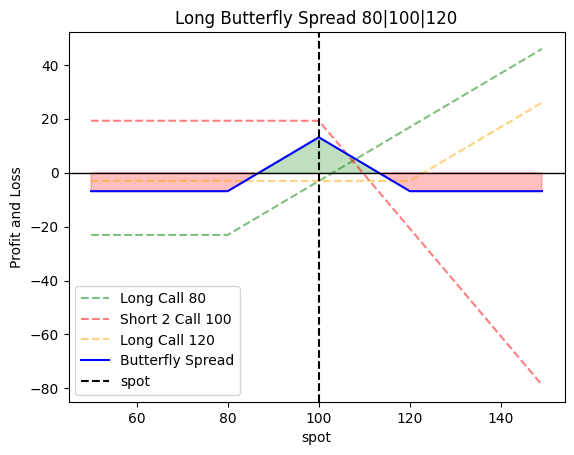

In [24]:
from plot import plot_payoff_butterfly_spread
plot_payoff_butterfly_spread(butterfly_spread)

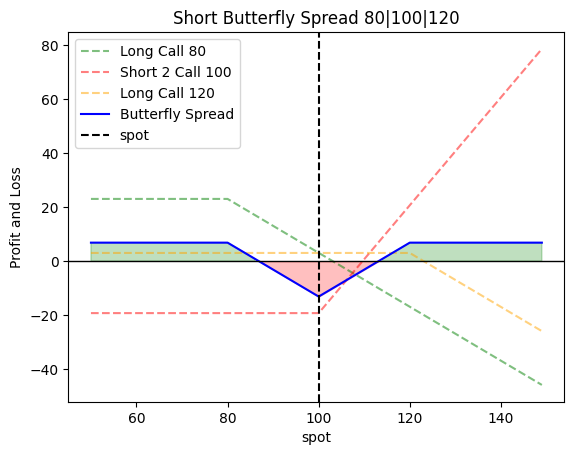

In [25]:
# Let's say you want to instead be long vol
butterfly_spread.qty = -1
plot_payoff_butterfly_spread(butterfly_spread)

<a id="section-ten"></a>
### **10. Digital Replication**

I’ve had this question several times during interviews. The code below has nothing to do with pricing, but rather replication.

It gives a better understanding of how digital/binary works.

The Digital or Binary option is an exotic option in which the payoff is either some fixed monetary amount or nothing at all.

The two main types of binary options are the cash-or-nothing binary option and the asset-or-nothing binary option.

We’ll focus only on the cash-or nothing digital/binary

It provides traders with the opportunity of a fixed payout when the market price of the underlying asset exceeds the strike price.

Digital options offer traders with two possible outcomes of any trade – traders earn a profit if their predictions are correct, else they must lose their initial output.

### Digital/binary payoff plot

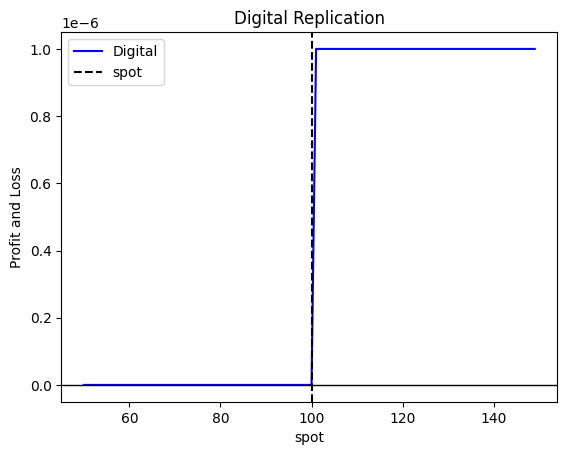

As you can see above, as soon as the underlying reaches the strike 100. The premium turns from 0 to 1

Now how do you replicate this payoff? 

If you remember previous option strategies, this payoff might suggest the bull spread.

We can be replicate the digital with two call options with different strikes. When we make the delta between those two strikes infinitely small and assume we have arbitrary strike prices. We get:

if we want to increase the premium received, we can buy more calls/bull spreads

See the graphs below

In [26]:
call1 = VanillaOption(style="euro", k=100, t=.2, way="call")
call2 = VanillaOption(style="euro", k=120, t=.2, way="call", qty=-1)

bsm = BlackScholesModel(spot=90, r=0.05, sigma=0.3)

In [27]:
call1.pricer(model=bsm)
call2.pricer(model=bsm)

{'spot': 90.0,
 'strike': 120.0,
 'maturity': 0.2,
 'value': 0.09735246926622976,
 'sigma': 0.3,
 'r': 0.05,
 'delta': -0.022383128703362808,
 'gamma': -0.0044478440742041015,
 'vega': -0.02161652220063193,
 'theta': 1.5243704155205653,
 'rho': 0.9667202615549277,
 'way': 'call',
 'model': 'BlackScholes',
 'pricing_date': '2023-07-18 13:51:14'}

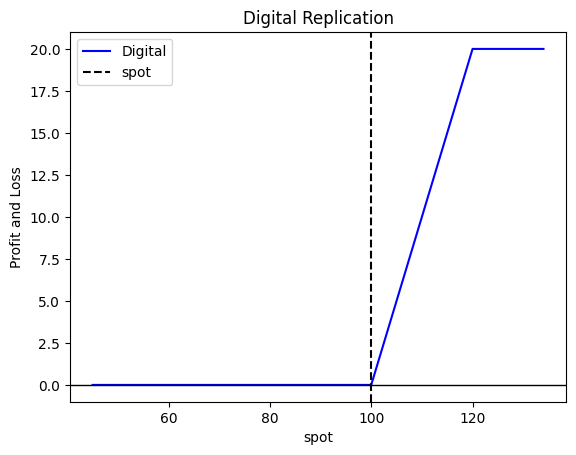

In [28]:
from plot import plot_payoff_digital_replication
plot_payoff_digital_replication(call1, call2,1)

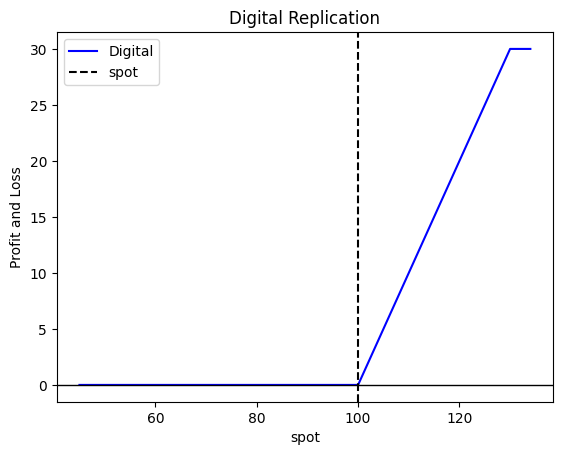

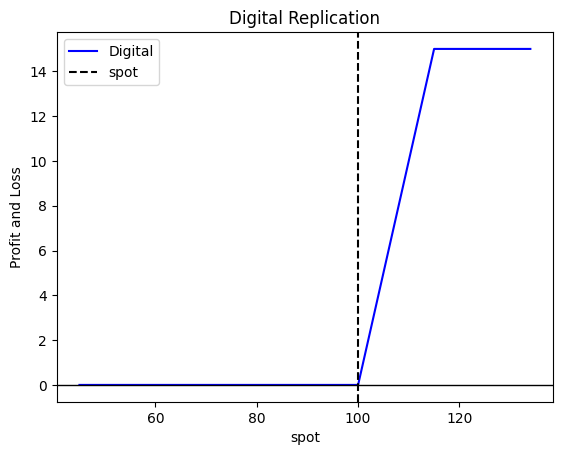

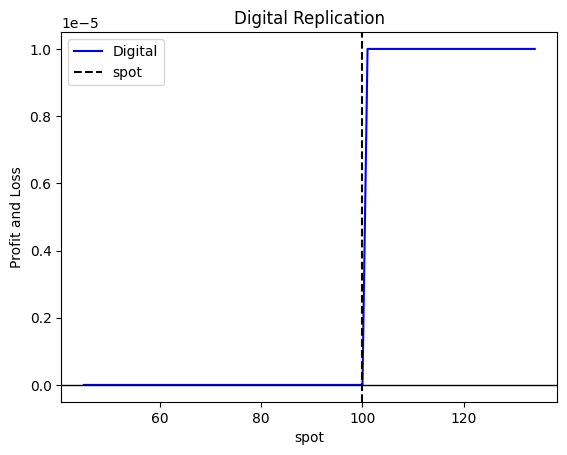

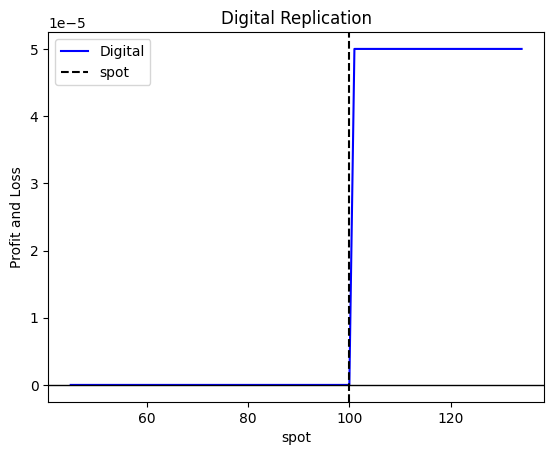

In [29]:
call2.k = 130
plot_payoff_digital_replication(call1, call2, 1)

call2.k = 115
plot_payoff_digital_replication(call1, call2, 1)

call2.k = 100.00001
plot_payoff_digital_replication(call1, call2, 1)

# let's make the qty bigger 
plot_payoff_digital_replication(call1, call2, 5)

Thank you for reading this short document. Don't hesitate if you'd like that I add a feature to my library. 